In [1]:
# Import libraries

# Standard libraries
from pathlib import Path
from collections import Counter
import random
import ast      # Abstract Syntax Tree

# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Models and evaluation libraries
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

import surprise
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import GridSearchCV

# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")
print(f"surprise version: {surprise.__version__}")

NumPy version: 2.4.1
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0
surprise version: 1.1.5


In [2]:
# Create image and model directories if they don't exist

rating_plots_dir = Path("plots/Rating_Distribution")
demo_plots_dir   = Path("plots/Demographics")
cont_plots_dir   = Path("plots/Content_Based")
coll_plots_dir   = Path("plots/Collaborative")
models_dir       = Path("models")

rating_plots_dir.mkdir(parents=True, exist_ok=True)
demo_plots_dir.mkdir(parents=True, exist_ok=True)
cont_plots_dir.mkdir(parents=True, exist_ok=True)
coll_plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Load Data and Preprocessing

In [3]:
# Load Data
# Credits.csv:          Cast and Crew                       In stringified JSON format
# keywords.csv:         Movie plot keywords                 In stringified JSON format
# links.csv:            TMDB and IMDB IDs for each movie
# movies_metadata.csv:  Movie information and metadata
# ratings.csv:          User ratings for each movie

# links_small.csv:      subset of links.csv for the small dataset
# ratings_small.csv:    subset of ratings.csv for the small dataset

data_folder = "./Movie data"

df_credits  = pd.read_csv(f"{data_folder}/credits.csv")
df_keywords = pd.read_csv(f"{data_folder}/keywords.csv")
df_ratings  = pd.read_csv(f"{data_folder}/ratings_small.csv")
df_metadata = pd.read_csv(f"{data_folder}/movies_metadata.csv",low_memory=False)
df_links    = pd.read_csv(f"{data_folder}/links_small.csv")

In [4]:
# Print the shapes of the dataframes

print(f"Credits shape: {df_credits.shape}")
print(f"Keywords shape: {df_keywords.shape}")
print(f"Ratings shape: {df_ratings.shape}")
print(f"Metadata shape: {df_metadata.shape}")
print(f"Links shape: {df_links.shape}")

Credits shape: (45476, 3)
Keywords shape: (46419, 2)
Ratings shape: (100004, 4)
Metadata shape: (45466, 24)
Links shape: (9125, 3)


## Merging Metadata, Keywords, Credits using Links

- `id` in **metadata / keywords / credits** is actually tmdb id

- `movie id` is used in **ratings** / **ratings_small**

- Use **links** to map the id 

In [5]:
# Convert id columns to integer type and remove nan and duplicate values

# Change all the id columns to integer type for comparison
df_links['tmdbId'] = pd.to_numeric(df_links['tmdbId'], errors='coerce')
df_metadata['id'] = pd.to_numeric(df_metadata['id'], errors='coerce')
df_keywords['id'] = pd.to_numeric(df_keywords['id'], errors='coerce')
df_credits['id'] = pd.to_numeric(df_credits['id'], errors='coerce')

# Remove nan and duplicate values from the dataframes
df_links = df_links.dropna(subset=['tmdbId']).drop_duplicates(subset=['tmdbId'])
df_metadata = df_metadata.dropna(subset=['id']).drop_duplicates(subset=['id'])
df_keywords = df_keywords.dropna(subset=['id']).drop_duplicates(subset=['id'])
df_credits = df_credits.dropna(subset=['id']).drop_duplicates(subset=['id'])

# Print the shapes of the dataframes after removing nan and duplicate values
print(f"Links shape: {df_links.shape}")
print(f"Metadata shape: {df_metadata.shape}")
print(f"Keywords shape: {df_keywords.shape}")
print(f"Credits shape: {df_credits.shape}")


Links shape: (9112, 3)
Metadata shape: (45433, 24)
Keywords shape: (45432, 2)
Credits shape: (45432, 3)


In [6]:
# Keep only the rows in the metadata, keywords, and credits dataframes that have a matching tmdbId in the links dataframe

df_links['tmdbId'] = df_links['tmdbId'].astype(int)
df_metadata['id'] = df_metadata['id'].astype(int)
df_keywords['id'] = df_keywords['id'].astype(int)
df_credits['id'] = df_credits['id'].astype(int)

df_metadata = df_metadata[df_metadata['id'].isin(df_links['tmdbId'])]
df_keywords = df_keywords[df_keywords['id'].isin(df_links['tmdbId'])]
df_credits  = df_credits[df_credits['id'].isin(df_links['tmdbId'])]

print(f"Shape of movies_metadata.csv after filtering: {df_metadata.shape}")
print(f"Shape of keywords.csv after filtering: {df_keywords.shape}")
print(f"Shape of credits.csv after filtering: {df_credits.shape}")

Shape of movies_metadata.csv after filtering: (9082, 24)
Shape of keywords.csv after filtering: (9082, 2)
Shape of credits.csv after filtering: (9082, 3)


In [7]:
# Rename title that have duplicate to "title (year)"

# Extract the year from the release_date column
df_metadata['year'] = pd.to_datetime(df_metadata['release_date'], errors='coerce').dt.year

# Convert the year to string and add parentheses around it, if the year is not NaN
df_metadata['year_str'] = df_metadata['year'].apply(
    lambda x: f" ({int(x)})" if pd.notna(x) else ""
)

# Find the duplicated titles in the metadata dataframe
# Keep = False means that all duplicates will be marked as True
duplicated_mask = df_metadata.duplicated(subset=['title'], keep=False)

# add the year to the title for the duplicated titles
df_metadata.loc[duplicated_mask, 'title'] = (
    df_metadata.loc[duplicated_mask, 'title'] 
    + df_metadata.loc[duplicated_mask, 'year_str']
)

# Drop the year and year_str columns from the metadata dataframe
df_metadata.drop(columns=['year', 'year_str'], inplace=True)

print(F"Renamed duplicated titles in the metadata dataframe. Number of duplicated titles: {duplicated_mask.sum()}")

Renamed duplicated titles in the metadata dataframe. Number of duplicated titles: 521


In [8]:
# Merge the metadata, keywords, and credits dataframes on the id column
df_metadata_merged = df_metadata.merge(df_keywords, on='id', how='left')
df_metadata_merged = df_metadata_merged.merge(df_credits, on='id', how='left')

# only keep the columns we need from the metadata dataframe
df_metadata_merged = df_metadata_merged[['id', 'title', 'vote_average', 'vote_count', 'adult', 'belongs_to_collection', 'genres', 'keywords', 'cast', 'crew']]

print(f"Shape of merged dataframe: {df_metadata_merged.shape}")
df_metadata_merged.head(5)

Shape of merged dataframe: (9082, 10)


,id,title,vote_average,vote_count,adult,belongs_to_collection,genres,keywords,cast,crew
0,862,Toy Story,7.7,5415.0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844,Jumanji,6.9,2413.0,False,NaN,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10090, 'name': 'board game'}, {'id': 1...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,15602,Grumpier Old Men,6.5,92.0,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...","[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,31357,Waiting to Exhale,6.1,34.0,False,NaN,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,11862,Father of the Bride Part II,5.7,173.0,False,"{'id': 96871, 'name': 'Father of the Bride Col...","[{'id': 35, 'name': 'Comedy'}]","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...","[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de..."


## Ratings (Convert `movie_id` to `id`)

In [9]:
# Sort the ratings dataset by timestamp and convert the timestamp to datetime format
# df_ratings = df_ratings.sort_values('timestamp')
df_ratings['timestamp'] = pd.to_datetime(df_ratings['timestamp'], unit='s')

# print the first and last timestamps
print(f"First timestamp: {df_ratings['timestamp'].min()}")
print(f"Last timestamp: {df_ratings['timestamp'].max()}")

# Check for missing values in the ratings dataset
print(f"Missing values in ratings dataset:\n{df_ratings.isna().sum()}")

First timestamp: 1995-01-09 11:46:49
Last timestamp: 2016-10-16 17:57:24
Missing values in ratings dataset:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [10]:
# Convert the `movie_id` column to `id` using the links dataframe
df_ratings_processed = df_ratings.merge(df_links[['movieId', 'tmdbId']], left_on='movieId', right_on='movieId', how='left')

# Rename the `tmdbId` column to `id` and drop na values
df_ratings_processed = df_ratings_processed.rename(columns={'tmdbId': 'id'}).dropna(subset=['id'])
# Convert the `id` column to integer type
df_ratings_processed['id'] = df_ratings_processed['id'].astype(int)
# Remove the `movieId` column as it is no longer needed
df_ratings_processed = df_ratings_processed.drop(columns=['movieId'])

# Only keep the ratings of movies that are present in the merged metadata dataframe
valid_ids = set(df_metadata_merged['id'])
df_ratings_processed = df_ratings_processed[df_ratings_processed['id'].isin(valid_ids)]

print(f"Remaining ratings count: {len(df_ratings_processed)}")

df_ratings_processed.head(5)

Remaining ratings count: 99810


,userId,rating,timestamp,id
0,1,2.5,2009-12-14 02:52:24,9909
1,1,3.0,2009-12-14 02:52:59,11360
2,1,3.0,2009-12-14 02:53:02,819
3,1,2.0,2009-12-14 02:53:05,1103
4,1,4.0,2009-12-14 02:53:25,11216


# Exploratory Data Analysis (EDA)

Number of ratings before 1996: 3
Number of ratings after 1996: 99807


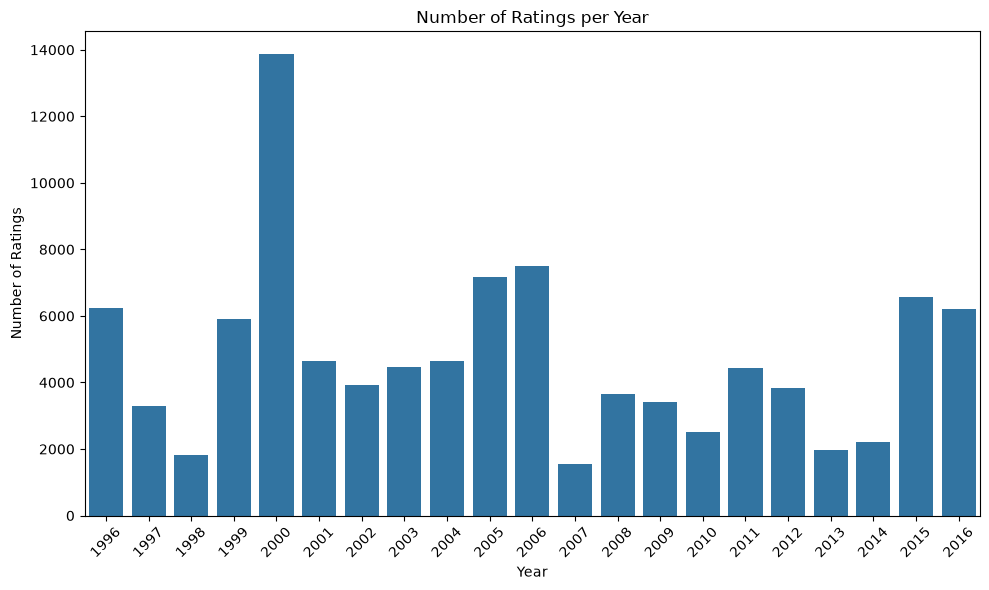

In [11]:
# Visualize the number of ratings per year

df_rating_plot = df_ratings_processed.copy()

# Change timestamp to datetime and sort the dataframe by timestamp
df_rating_plot['timestamp'] = pd.to_datetime(df_rating_plot['timestamp'], unit='s')
df_rating_plot = df_rating_plot.sort_values(by='timestamp').reset_index(drop=True)

# Remove data before 1996
print(f"Number of ratings before 1996: {len(df_rating_plot[df_rating_plot['timestamp'].dt.year < 1996])}")
df_rating_plot = df_rating_plot[df_rating_plot['timestamp'].dt.year >= 1996]
print(f"Number of ratings after 1996: {len(df_rating_plot)}")

# Group the ratings by year and count the number of ratings per year
rating_counts = df_rating_plot['timestamp'].groupby(df_rating_plot['timestamp'].dt.year).count()

# Plot the number of ratings per year
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Number of Ratings per Year')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(rating_plots_dir / "01_ratings_per_year.png")
plt.show()


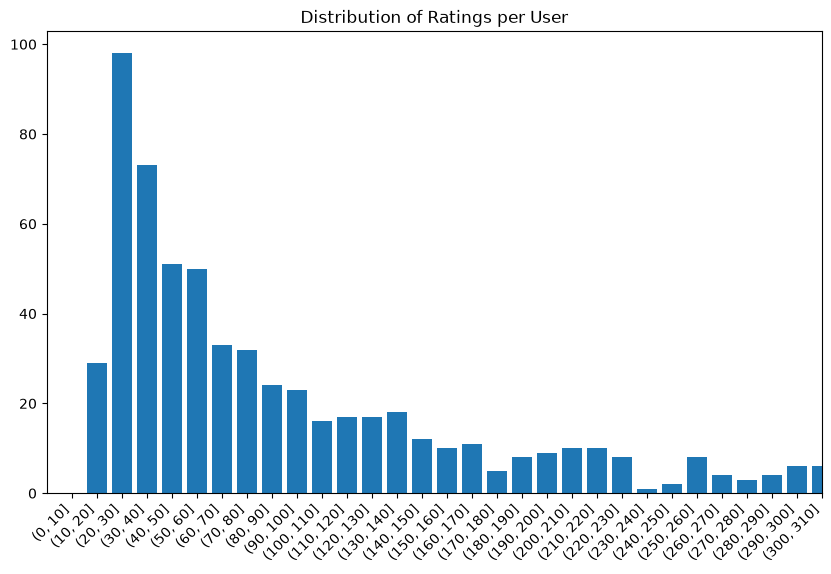

In [12]:
# Visualize the distribution of ratings per user

user_rating_counts = df_rating_plot['userId'].value_counts()

bins = range(0, user_rating_counts.max() + 11, 10)
binned_counts = pd.cut(user_rating_counts, bins=bins).value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(binned_counts.index.astype(str), binned_counts.values)
plt.xticks(rotation=45, ha='right')
plt.xlim(-1, 30)        # Show only the first 30 bins
plt.title('Distribution of Ratings per User')
plt.savefig(rating_plots_dir / "02_ratings_per_user.png")
plt.show()

# 1. Demographic Filtering

$$WeightedRating = \left( \frac{v}{v + m} \cdot R \right) + \left( \frac{m}{v + m} \cdot C \right)$$

-   **v**: The number of votes (or ratings) received by the specific item.
-   **m**: The minimum number of votes required to be listed in the rankings (a threshold to ensure statistical significance).
-   **R**: The average rating of the specific item (the mean of the v votes).
-   **C**: The mean (average) rating across the entire dataset.

In [13]:
# The funciton for calculating the weighted rating of a movie

def cal_weighted_rating_score(df):
    df = df.copy()

    c = df['vote_average'].mean()           # mean vote across the whole report (average rating)
    m = df['vote_count'].quantile(0.95)     # minimum votes
    print(f"Mean vote (c): {c}")
    print(f"Minimum votes (m): {m}")

    # Optional: Filter out movies that have less than the minimum number of votes
    # df = df[df['vote_count'] >= m]          
    # print(f"Number of movies with more than {m} votes: {len(df)}")

    # Calculate the weighted rating for each movie
    v = df['vote_count']
    r = df['vote_average']
    df['score'] = (v / (v + m) * r) + (m / (v + m) * c)
    
    df.to_csv('models/movie_score.csv', index=False)  # Save the DataFrame to a CSV file

    return df.sort_values('score', ascending=False)

df_metadata_merged = cal_weighted_rating_score(df_metadata_merged)

# print the top 10 movies (only the title, vote_count, vote_average, and score columns)
print(df_metadata_merged[['title', 'vote_count', 'vote_average', 'score']].head(10))

Mean vote (c): 6.362177934375689
Minimum votes (m): 2079.949999999999
                                              title  vote_count  vote_average  \
284                        The Shawshank Redemption      8358.0           8.5   
6897                                The Dark Knight     12269.0           8.3   
2369                                     Fight Club      9678.0           8.3   
692                                   The Godfather      6024.0           8.5   
266                                    Pulp Fiction      8670.0           8.3   
7550                                      Inception     14075.0           8.1   
8501                                   Interstellar     11187.0           8.1   
321                                    Forrest Gump      8147.0           8.2   
5018  The Lord of the Rings: The Return of the King      8226.0           8.1   
949                         The Empire Strikes Back      5998.0           8.2   

         score  
284   8.074000  
6897

In [14]:
# Save the movie_score dataframe to a CSV file

movie_score = df_metadata_merged[['title', 'vote_count', 'vote_average', 'score']]
movie_score.to_csv(models_dir / 'movie_score.csv', index=False)  

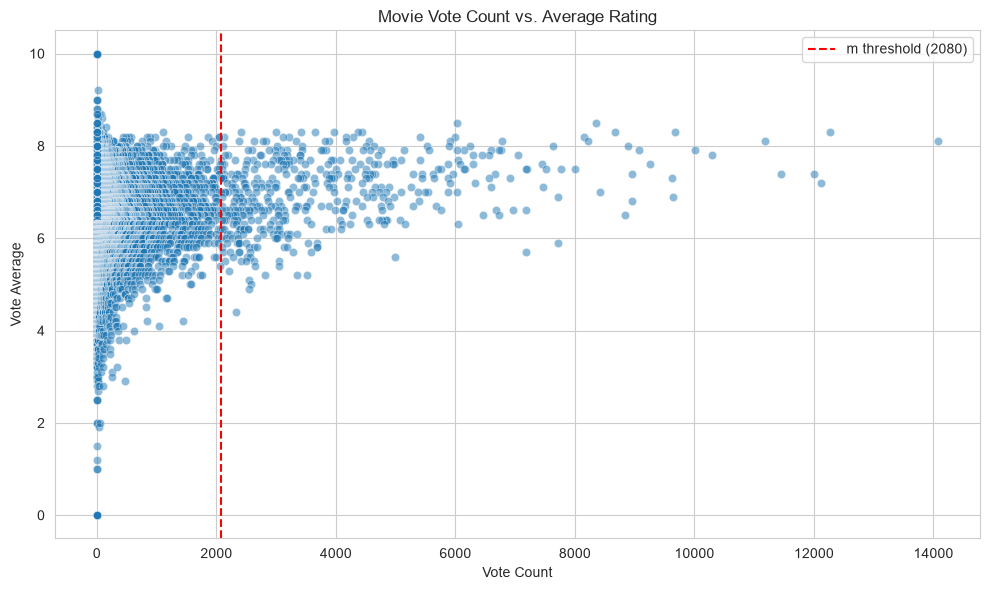

In [15]:
# Visualize the relationship between vote_count and vote_average

# Set theme style of the plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create a scatter plot of vote_count vs vote_average
sns.scatterplot(data=movie_score, x='vote_count', y='vote_average', alpha=0.5)

# Add a vertical line at the 95th percentile of vote_count to indicate the threshold for minimum votes
m = movie_score['vote_count'].quantile(0.95)
plt.axvline(x=m, color='red', linestyle='--', label=f'm threshold ({m:.0f})')

plt.title('Movie Vote Count vs. Average Rating')
plt.xlabel('Vote Count')
plt.ylabel('Vote Average')
plt.legend()
plt.tight_layout()
plt.savefig(demo_plots_dir / '01_vote_count_vs_average_rating.png')
plt.show()

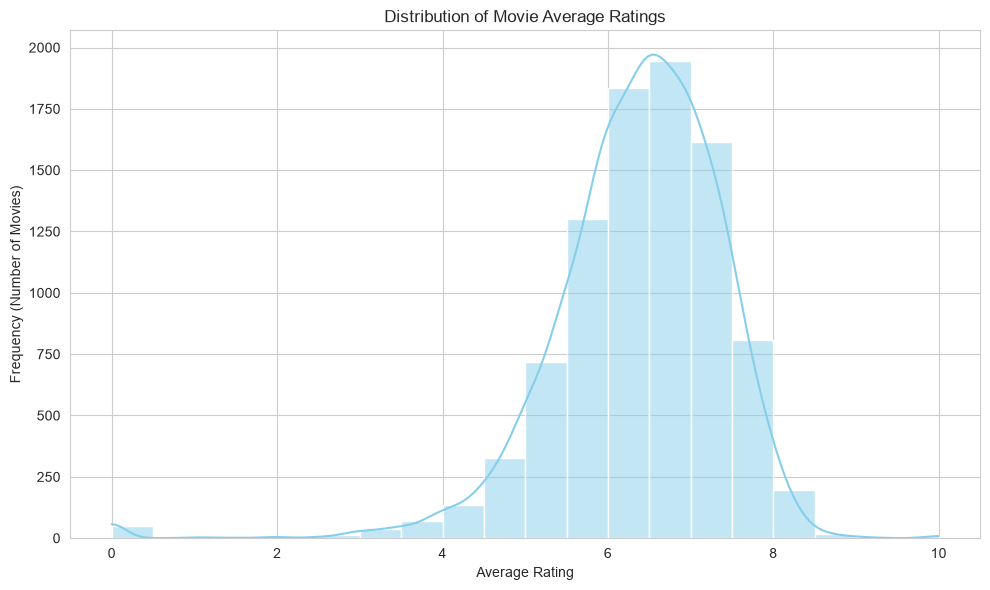

In [16]:
# Visualize the distribution of movie average ratings
plt.figure(figsize=(10, 6))

sns.histplot(movie_score['vote_average'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of Movie Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency (Number of Movies)')
plt.tight_layout()
plt.savefig(demo_plots_dir / '02_distribution_of_movie_average_ratings.png')
plt.show()

# 2. Content Based Filtering

In [17]:
# Function to extract keywords, genres, collection, director, screenplay, and top cast from the metadata

# 1. Basic Text Cleaning Helper
def clean_feature(x):
    if isinstance(x, str):
        return x.lower().replace(" ", "")
    return ''

def clean_list(l):
    return [clean_feature(i) for i in l if i]

# 2. Safe JSON/String Evaluation Helper
def safe_eval(x):
    if pd.isna(x) or not x:
        return None
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return None
    return x

# -------------------------------------------------------------
# Feature Extractors
# -------------------------------------------------------------

def get_keywords(x, num_keywords=10):
    data = safe_eval(x)
    if isinstance(data, list):
        return clean_list([i.get('name') for i in data[:num_keywords]])
    return []

def get_genres(x, num_genres=5):
    data = safe_eval(x)
    if isinstance(data, list):
        return clean_list([i.get('name') for i in data[:num_genres]])
    return []

def get_top_cast(x, num_cast=3):
    data = safe_eval(x)
    if isinstance(data, list):
        return clean_list([i.get('name') for i in data[:num_cast]])
    return []

def get_collection(x):
    data = safe_eval(x)
    if isinstance(data, dict):
        return clean_feature(data.get('name'))
    return ''

# Universal Crew Extractor（Director / Screenplay ...）
def get_crew_by_job(x, job_title='Director'):
    data = safe_eval(x)
    if isinstance(data, list):
        for i in data:
            if i.get('job') == job_title:
                return clean_feature(i.get('name'))
    return ''

In [18]:
# Extract features from the metadata dataframe
df_content = df_metadata_merged.copy()

# Apply the feature extractors to the metadata dataframe
df_content['keywords_list'] = df_content['keywords'].apply(get_keywords)
df_content['genres_list']   = df_content['genres'].apply(get_genres)
df_content['top_cast']      = df_content['cast'].apply(get_top_cast)
df_content['collection']    = df_content['belongs_to_collection'].apply(get_collection)

# Crew Features (Director / Screenplay)
df_content['director']    = df_content['crew'].apply(lambda x: get_crew_by_job(x, job_title='Director'))
df_content['screenplay']  = df_content['crew'].apply(lambda x: get_crew_by_job(x, job_title='Screenplay'))

# Create a "soup" of keywords, genres, collection, director, screenplay, and top cast for each movie
def create_soup(row):
    return f"{' '.join(row['keywords_list'])} {' '.join(row['genres_list'])} {row['collection']} {row['director']} {row['screenplay']} {' '.join(row['top_cast'])}"

df_content['soup'] = df_content.apply(create_soup, axis=1)

# Keep only the necessary columns for the content-based recommendation system
df_content = df_content[['title', 'id', 'vote_average', 'vote_count', 'score', 'keywords_list', 'genres_list', 'collection', 'director', 'screenplay', 'top_cast', 'soup']]
df_content.to_parquet('models/movie_content.parquet', index=False)  # Use Parquet format to preserve data types and for better performance and smaller file size

In [19]:
# Get the matrix and vectorizer for a given feature column in the dataframe

def get_matrix_and_vectorizer(column_name, vectorizer_type='count', binary=True):
    # Convert List format to Space-separated String
    series_text = df_content[column_name].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else (x if pd.notna(x) else '')
    )
    
    # Choose Vectorizer type
    if vectorizer_type == 'count':
        vectorizer = CountVectorizer(binary=binary, stop_words='english')
    else:
        vectorizer = TfidfVectorizer(stop_words='english')
    
    # Fit and transform the text data to create the matrix
    matrix = vectorizer.fit_transform(series_text)
    return matrix, vectorizer

# Define the Vectorizer for each Feature (Soup is recommended to use Count, to avoid popular actors/directors being penalized by TF-IDF)
feature_configs = {
    'soup'      : ('soup', 'count', True),
    'keywords'  : ('keywords_list', 'tfidf', False),
    'genres'    : ('genres_list', 'count', True),
    'collection': ('collection', 'count', True),
    'director'  : ('director', 'count', True),
    'screenplay': ('screenplay', 'count', True),
    'cast'      : ('top_cast', 'count', True),
}

# Reset the index of the dataframe to ensure that the indices are sequential and start from 0 
# which is important for matrix operations and indexing later on.
df_content = df_content.reset_index(drop=True)

matrices = {}
vectorizers = {}

for feature_name, (col, v_type, is_binary) in feature_configs.items():
    matrix, vectorizer = get_matrix_and_vectorizer(col, vectorizer_type=v_type, binary=is_binary)
    matrices[feature_name] = matrix
    vectorizers[feature_name] = vectorizer

# Create a folder to save the matrices and vectorizers
matrix_folder = Path('./models/matrices')
matrix_folder.mkdir(parents=True, exist_ok=True)

# 1. Save Sparse Matrices
for feature, matrix in matrices.items():
    joblib.dump(matrix, matrix_folder / f"{feature}_matrix.pkl")

# 2. Save Vectorizers
for feature, vectorizer in vectorizers.items():
    joblib.dump(vectorizer, matrix_folder / f"{feature}_vectorizer.pkl")

print("All matrices and vectorizers saved successfully!")

All matrices and vectorizers saved successfully!


In [20]:
# Content-Based Recommendation System

DEFAULT_WEIGHTS = {
    'keywords'  : 0.25,
    'genres'    : 0.25,
    'collection': 0.10,
    'director'  : 0.15,
    'screenplay': 0.10,
    'cast'      : 0.15
}

def content_based_recommendations(
    movie_input, 
    use_weighted=True, 
    custom_weights=None, 
    num_recs=10, 
    min_vote_count=10
):
    """
    On-the-fly calculation of Content-Based Recommendations
    Supports single or multiple movie inputs.
    """
    # 1. Process input, convert to list if it's a single string
    titles = [movie_input] if isinstance(movie_input, str) else movie_input
    
    # 2. Find Target Movies' Indices
    target_indices = []
    for t in titles:
        # Exact Match
        match = df_content[df_content['title'].str.lower() == t.lower()]
        
        # Contains Match
        if match.empty:
            match = df_content[df_content['title'].str.contains(t, case=False, na=False)]

        # If still no match, print a warning and continue to the next title
        if match.empty:
            print(f"⚠️ Movie not found: '{t}'")
            continue
            
        target_indices.append(match.index[0])

    if not target_indices:
        print("❌ No valid movies found in input.")
        return pd.DataFrame()

    num_movies = df_content.shape[0]
    final_scores = np.zeros(num_movies)

    # 3. Calculate Similarity Scores of the target movies against all movies

    # A : Weighted Approach
    if use_weighted:
        weights = custom_weights if custom_weights else DEFAULT_WEIGHTS
        
        # Check if weights sum to 1
        weight_sum = sum(weights.values())
        if not np.isclose(weight_sum, 1.0):
            raise ValueError(f"Weights must sum to 1. Current sum: {weight_sum:.2f}")
            
        # Calculate weighted similarity scores
        for key, weight in weights.items():
            if key in matrices:
                # Only calculate similarity of Target Rows against the entire matrix (very fast)
                sim = cosine_similarity(matrices[key][target_indices], matrices[key], dense_output=False)
                sim_mean = np.array(sim.mean(axis=0)).flatten()     # Mean across targets for multiple movies
                final_scores += sim_mean * weight

    # B : Soup Only Approach
    else:
        sim = cosine_similarity(matrices['soup'][target_indices], matrices['soup'], dense_output=False)
        final_scores = np.array(sim.mean(axis=0)).flatten()

    # Use a temporary DataFrame for sorting and filtering (to avoid Apply/Index misalignment issues)
    df_scores = df_content.copy()           
    df_scores['sim_score'] = final_scores
    df_scores = df_scores.drop(index=target_indices, errors='ignore')

    # Filter out movies with low vote_count (to avoid recommending extremely unpopular or unrated movies)
    qualified = df_scores[df_scores['vote_count'] >= min_vote_count].copy()
    
    # Fallback Guard: If the number of qualified movies is less than the requested number, return the unfiltered results
    if len(qualified) < num_recs:
        qualified = df_scores.copy()

    # 7. Sort by similarity score and return the top N recommendations
    recommendations = qualified.sort_values(by='sim_score', ascending=False).head(num_recs)

    return recommendations[['id', 'title', 'sim_score']].reset_index(drop=True)


# Example usage of the content-based recommendation system
movie_input =  ["Inception"]

recommendations_weighted = content_based_recommendations(movie_input, use_weighted=True, num_recs=10)
print("Recommendations with weighted features:")
print(recommendations_weighted)

recommendations_soup = content_based_recommendations(movie_input, use_weighted=False, num_recs=10)
print("Recommendations with soup feature only:")
print(recommendations_soup)

Recommendations with weighted features:
       id                                  title  sim_score
0      77                                Memento   0.408114
1    1124                           The Prestige   0.379099
2   49026                  The Dark Knight Rises   0.361803
3     155                        The Dark Knight   0.361803
4     272                          Batman Begins   0.314550
5   11660                              Following   0.314550
6  157336                           Interstellar   0.279099
7     320                        Insomnia (2002)   0.279099
8   59967                                 Looper   0.268649
9    5137  Sky Captain and the World of Tomorrow   0.250000
Recommendations with soup feature only:
       id                                  title  sim_score
0    9620                               Paycheck   0.314970
1   10596                              Replicant   0.314270
2     157    Star Trek III: The Search for Spock   0.314270
3    5137  Sky Capta

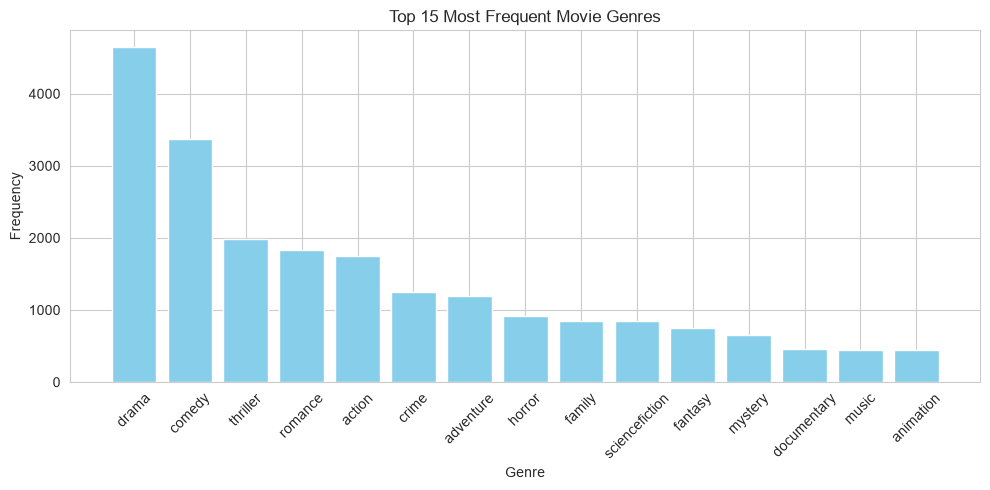

In [21]:
# Visualize the most frequent movie genres in the dataset

# Count the frequency of each genre in the 'genres_list' column of the df_content dataframe
genre_counts = Counter([genre for list_ in df_content['genres_list'] for genre in list_])
genres_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values('Count', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(genres_df['Genre'][:15], genres_df['Count'][:15], color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 15 Most Frequent Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(cont_plots_dir / '05_top_15_movie_genres.png')
plt.show()

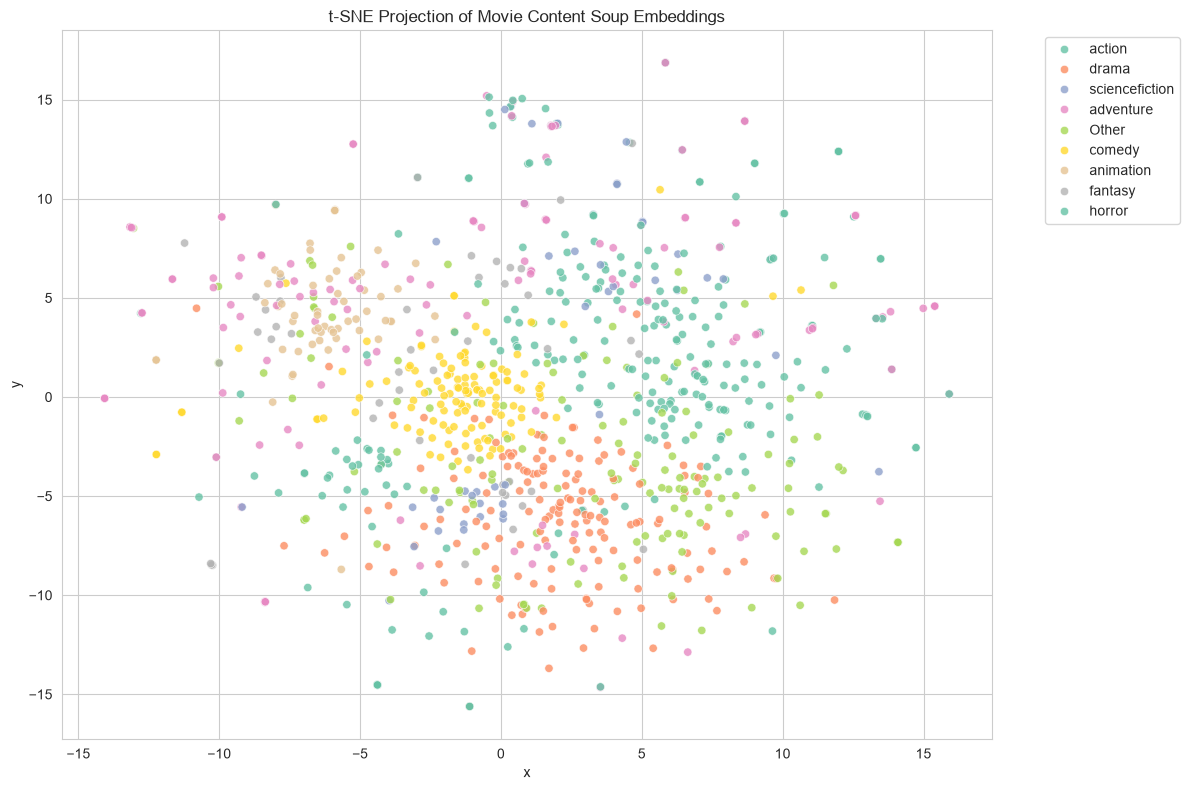

In [22]:
# Visualize the t-SNE projection of the movie content soup embeddings

# Pick the top 1000 movies based on vote_count for visualization
sample_df = df_content.sort_values('vote_count', ascending=False).head(1000).copy()
sample_indices = sample_df.index
sample_matrix = matrices['soup'][sample_indices].toarray()

# Extract the primary genre for each movie to use as a label
sample_df['primary_genre'] = sample_df['genres_list'].apply(lambda x: x[0] if len(x)>0 else 'Unknown')

# t-SNE dimensionality reduction to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(sample_matrix)

sample_df['x'] = tsne_results[:, 0]
sample_df['y'] = tsne_results[:, 1]

plt.figure(figsize=(12, 8))

# Define the top 8 genres to be displayed in the plot, and group all other genres under 'Other'
top_genres = sample_df['primary_genre'].value_counts().head(8).index
sample_df['plot_genre'] = sample_df['primary_genre'].apply(lambda x: x if x in top_genres else 'Other')

sns.scatterplot(x='x', y='y', hue='plot_genre', data=sample_df, palette='Set2', alpha=0.8)
plt.title('t-SNE Projection of Movie Content Soup Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(cont_plots_dir / '06_tsne_movie_genres.png')
plt.show()

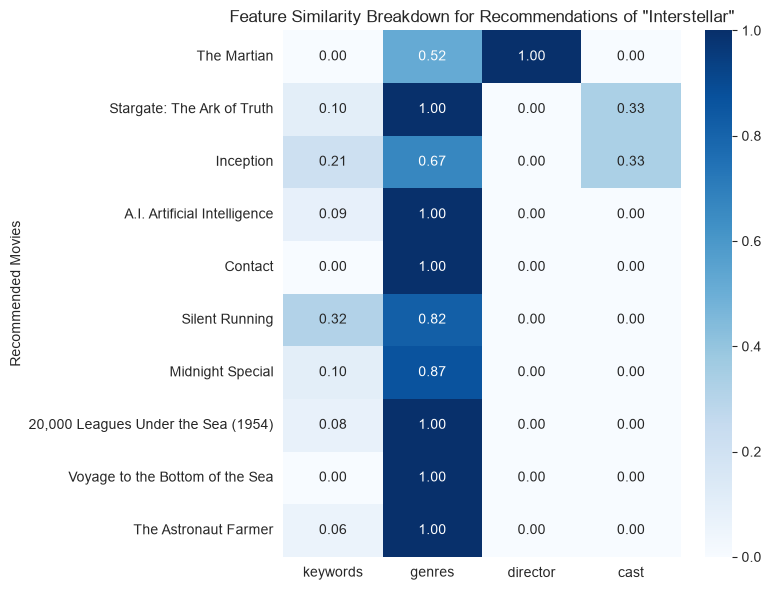

In [23]:
# Visualize the feature similarity breakdown for the recommendations of a target movie

# Take Interstellar as an example
target_movie = "Interstellar"
recs = content_based_recommendations(target_movie, use_weighted=True, num_recs=10)
rec_indices = df_content[df_content['title'].isin(recs['title'])].index
target_idx = df_content[df_content['title'].str.lower() == target_movie.lower()].index[0]

# Calculate the similarity scores for each feature between the target movie and the recommended movies
sim_matrix_data = {}
for feat in ['keywords', 'genres', 'director', 'cast']:
    sim = cosine_similarity(matrices[feat][target_idx], matrices[feat][rec_indices]).flatten()
    sim_matrix_data[feat] = sim

sim_df = pd.DataFrame(sim_matrix_data, index=recs['title'])

plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Feature Similarity Breakdown for Recommendations of "{target_movie}"')
plt.ylabel('Recommended Movies')
plt.tight_layout()
plt.savefig(cont_plots_dir / '07_feature_similarity_breakdown.png')
plt.show()

# 3. Collaborative Filtering with SVD

In [24]:
# df_metadata_merged
# df_ratings_processed